# Read simulation data

(continue running from here to change the figures without having to run simulation again)

In [132]:
import pickle

with open("sim_data.pkl", "rb") as f:
    dfs = pickle.load(f)
df_baseline, df_1x, df_5x, df_10x = dfs["df_baseline"], dfs["df_p"], dfs["df_5p"], dfs["df_10p"]

/tmp/ipykernel_3680372/2004659764.py:4: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  dfs = pickle.load(f)


# Plot

In [133]:
import os
figures_path = "figures/"
os.makedirs(figures_path, exist_ok=True)

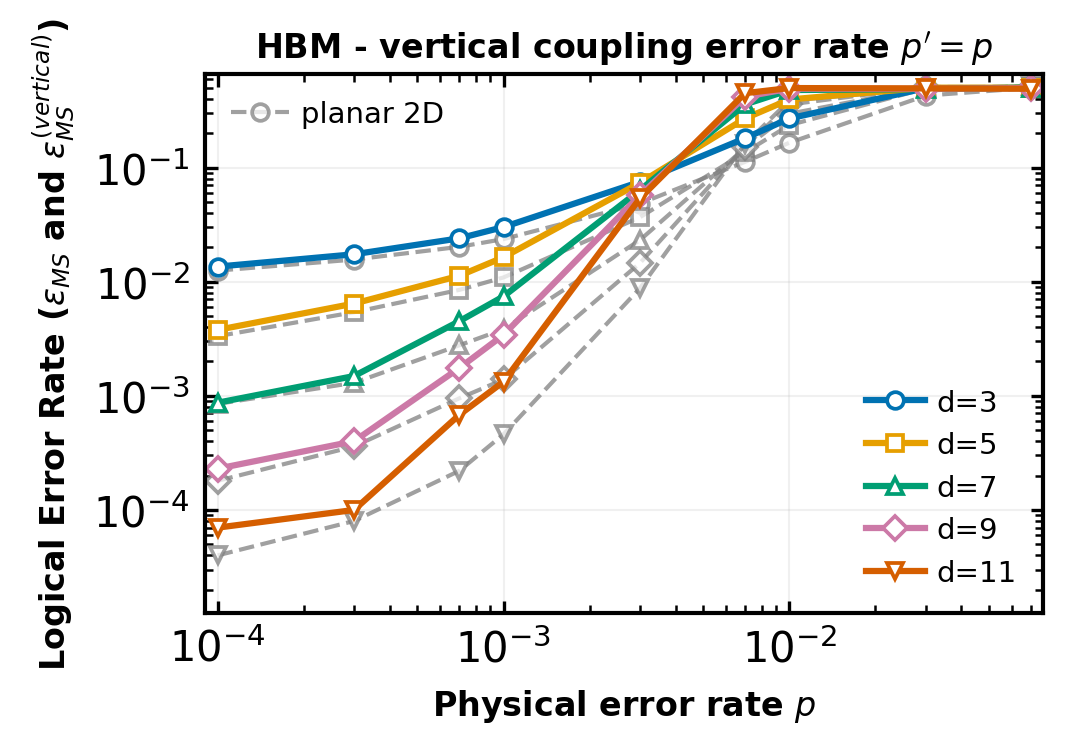

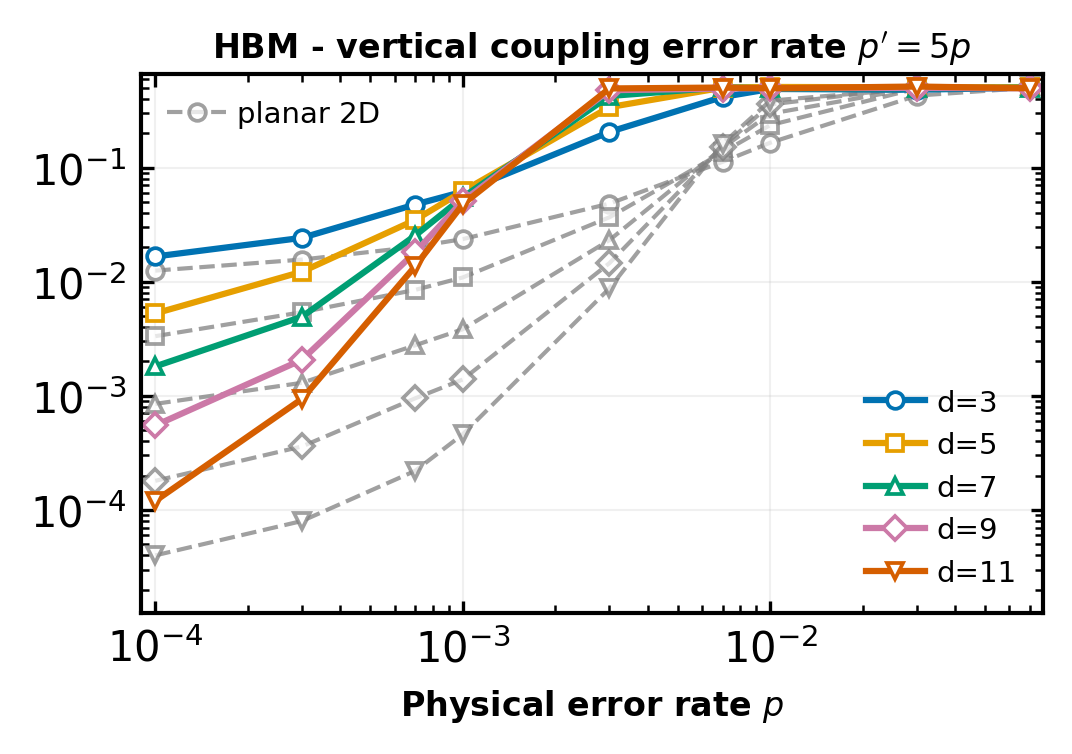

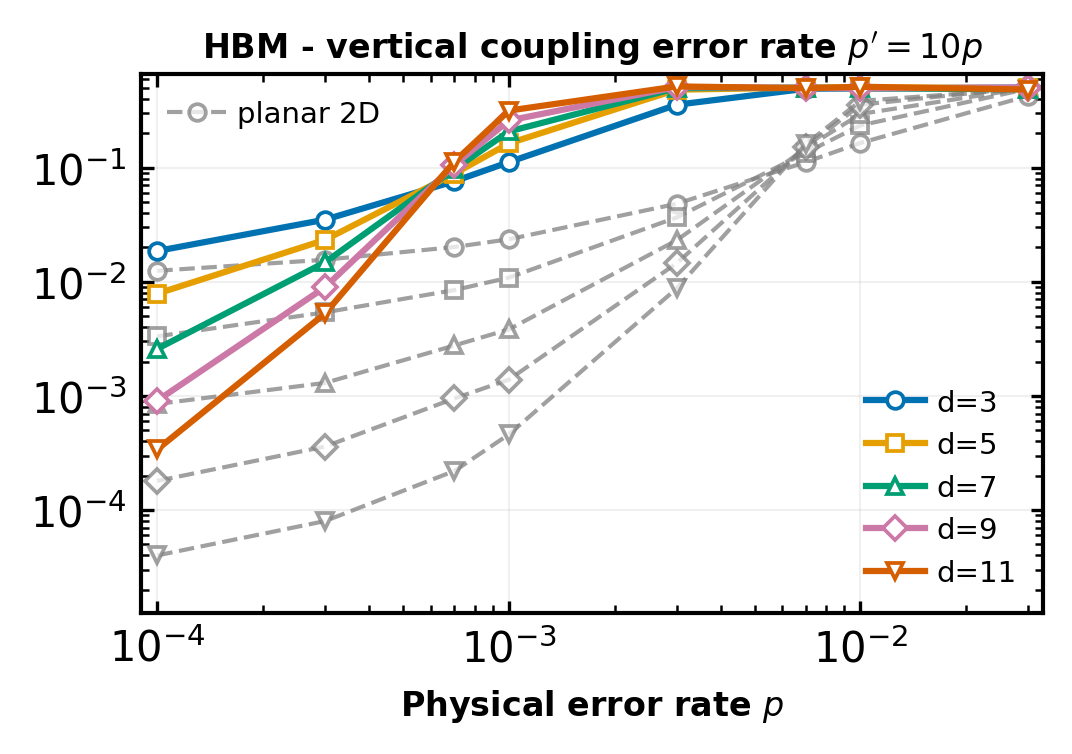

In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def wilson_interval(k, n, z=1.96):
    if n == 0:
        return np.nan, np.nan

    p = k / n
    denom = 1.0 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    lo = max(center - half, 1e-12)
    hi = min(center + half, 1.0)
    return lo, hi


def prepare_plot_df(df):
    g = (
        df.groupby(["mode", "distance", "p"], as_index=False)[["shots", "errors"]]
        .sum()
        .sort_values(["mode", "distance", "p"])
    )

    g["ler"] = g["errors"] / g["shots"]
    ci = np.array([wilson_interval(k, n) for k, n in zip(g["errors"], g["shots"])])
    g["ler_lo"] = ci[:, 0]
    g["ler_hi"] = ci[:, 1]
    return g


def set_publication_style():
    plt.rcdefaults()

    plt.rcParams.update({
        "figure.dpi": 300,
        "savefig.dpi": 600,
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "legend.fontsize": 7,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.linewidth": 1,
        "lines.linewidth": 1.5,
        "lines.markersize": 4,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.minor.width": 0.6,
        "ytick.minor.width": 0.6,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 3.0,
        "ytick.major.size": 3.0,
        "xtick.minor.size": 2.0,
        "axes.labelweight": "bold", 
        "axes.titleweight": "bold",
        "ytick.minor.size": 2.0,
        "legend.frameon": False,
    })



def estimate_threshold(sub_df):
    """
    Estimate threshold from crossings between adjacent code-distance curves.
    Works in log-log space and returns the median crossing point.
    """
    distances = sorted(sub_df["distance"].unique())
    crossings = []

    for d1, d2 in zip(distances[:-1], distances[1:]):
        s1 = sub_df[sub_df["distance"] == d1][["p", "ler"]].sort_values("p")
        s2 = sub_df[sub_df["distance"] == d2][["p", "ler"]].sort_values("p")

        merged = pd.merge(s1, s2, on="p", suffixes=("_1", "_2")).dropna()
        if len(merged) < 2:
            continue

        x = np.log10(merged["p"].to_numpy())
        ydiff = np.log10(merged["ler_1"].to_numpy()) - np.log10(merged["ler_2"].to_numpy())

        for i in range(len(x) - 1):
            y0, y1 = ydiff[i], ydiff[i + 1]

            if y0 == 0:
                crossings.append(10 ** x[i])
                continue

            if y0 * y1 < 0:
                # linear interpolation in log p
                xc = x[i] - y0 * (x[i + 1] - x[i]) / (y1 - y0)
                crossings.append(10 ** xc)

    if len(crossings) == 0:
        return None

    return float(np.min(crossings))

def plot_micro_ler_single(df, mode, is_first, outname=None): # Added is_first parameter
    set_publication_style()
    plot_df = prepare_plot_df(df)

    title_map = {
        1.0: r"HBM - vertical coupling error rate $p' = p$",
        5.0: r"HBM - vertical coupling error rate $p' = 5p$",
        10.0: r"HBM - vertical coupling error rate $p' = 10p$",
    }

    distances = sorted(plot_df["distance"].unique())
    color_map  = {3: "#0072B2", 5: "#E69F00", 7: "#009E73", 9: "#CC79A7", 11: "#D55E00"}
    marker_map = {3: "o",       5: "s",       7: "^",       9: "D",       11: "v"}

    COLUMNWIDTH_PT = 250
    fig_width = COLUMNWIDTH_PT / 72.27

    fig, ax = plt.subplots(figsize=(fig_width, 2.4), constrained_layout=True)

    sub = plot_df[plot_df["mode"] == mode].copy()
    sub_base = plot_df[plot_df["mode"] == 0].copy()

    all_lo = pd.concat([sub["ler_lo"], sub_base["ler_lo"]])
    all_hi = pd.concat([sub["ler_hi"], sub_base["ler_hi"]])
    y_positive = all_lo[all_lo > 0]
    y_min = max(y_positive.min() * 0.8, 1e-6) if len(y_positive) else 1e-6
    y_max = min(all_hi.max() * 1.25, 1.0)

    hbm_handles, hbm_labels = [], []

    # --- Baseline ---
    base_distances = sorted(sub_base["distance"].unique())
    baseline_proxy = None
    for d in base_distances:
        s = sub_base[sub_base["distance"] == d].sort_values("p")
        if s.empty: continue
        line, = ax.plot(s["p"], s["ler"], color="0.5", marker=marker_map.get(d, "o"), 
                        markerfacecolor="white", markeredgewidth=0.9, linestyle="--", linewidth=1.0, alpha=0.75)
        if baseline_proxy is None: baseline_proxy = line

    # --- HBM mode curves ---
    for d in distances:
        s = sub[sub["distance"] == d].sort_values("p")
        if s.empty: continue
        line, = ax.plot(s["p"], s["ler"], color=color_map.get(d), marker=marker_map.get(d, "o"), 
                        markerfacecolor="white", markeredgewidth=0.9)
        hbm_handles.append(line)
        hbm_labels.append(f"d={d}")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(sub["p"].min() * 0.9, sub["p"].max() * 1.1)
    ax.set_ylim(y_min, y_max)
    ax.grid(True, which="major", alpha=0.18, linewidth=0.5)
    ax.tick_params(which="both", top=True, right=True)
    ax.set_title(title_map[mode], pad=4)
    ax.set_xlabel("Physical error rate $p$")

    # --- MODIFIED PORTION ---
    # Only set the Y label if this is the first plot
    if is_first:
        ax.set_ylabel(r"Logical Error Rate ($\varepsilon_{MS}$ and $\varepsilon_{MS}^{(vertical)}$)")
    # -------------------------

    leg_hbm = ax.legend(hbm_handles, hbm_labels, ncol=1, loc="lower right", columnspacing=0.9, handletextpad=0.4)
    ax.add_artist(leg_hbm)

    if baseline_proxy is not None:
        ax.legend([baseline_proxy], ["planar 2D"], loc="upper left", handletextpad=0.4)

    if outname is None:
        outname = os.path.join(figures_path, f"ls_ler_{mode}")
    fig.savefig(f"{outname}.pdf", bbox_inches="tight", pad_inches=0.05, dpi=600)
    plt.show()


def plot_micro_ler(df, outname):
    modes = [1.0, 5.0, 10.0]
    name_map = {1.0: "1x", 5.0: "5x", 10.0: "10x"}
    
    # Use enumerate to track the index
    for i, mode in enumerate(modes):
        # is_first is True only when index is 0
        plot_micro_ler_single(df, mode, is_first=(i == 0), outname=outname + "_" + name_map[mode])


df_all = pd.concat([df_baseline, df_1x, df_5x, df_10x], ignore_index=True)
plot_micro_ler(df_all, f"{figures_path}LS_vertical_interconnect")

#####################################################################################

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import os

# def wilson_interval(k, n, z=1.96):
#     if n == 0:
#         return np.nan, np.nan
#     p = k / n
#     denom = 1.0 + z**2 / n
#     center = (p + z**2 / (2 * n)) / denom
#     half = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
#     lo = max(center - half, 1e-12)
#     hi = min(center + half, 1.0)
#     return lo, hi

# def prepare_plot_df(df):
#     g = (
#         df.groupby(["mode", "distance", "p"], as_index=False)[["shots", "errors"]]
#         .sum()
#         .sort_values(["mode", "distance", "p"])
#     )
#     g["ler"] = g["errors"] / g["shots"]
#     ci = np.array([wilson_interval(k, n) for k, n in zip(g["errors"], g["shots"])])
#     g["ler_lo"] = ci[:, 0]
#     g["ler_hi"] = ci[:, 1]
#     return g

# def set_publication_style():
#     plt.rcdefaults()
#     plt.rcParams.update({
#         "figure.dpi": 300,
#         "savefig.dpi": 600,
#         "font.size": 8,
#         "axes.labelsize": 8,
#         "axes.titlesize": 8,
#         "legend.fontsize": 7,
#         "xtick.labelsize": 8,  # Adjusted for subplots
#         "ytick.labelsize": 8,  # Adjusted for subplots
#         "axes.linewidth": 1,
#         "lines.linewidth": 1.2,
#         "lines.markersize": 3,
#         "xtick.major.width": 0.8,
#         "ytick.major.width": 0.8,
#         "xtick.direction": "in",
#         "ytick.direction": "in",
#         "xtick.major.size": 3.0,
#         "ytick.major.size": 3.0,
#         "axes.labelweight": "bold", 
#         "axes.titleweight": "bold",
#         "legend.frameon": False,
#     })

# def estimate_threshold(sub_df):
#     distances = sorted(sub_df["distance"].unique())
#     crossings = []
#     for d1, d2 in zip(distances[:-1], distances[1:]):
#         s1 = sub_df[sub_df["distance"] == d1][["p", "ler"]].sort_values("p")
#         s2 = sub_df[sub_df["distance"] == d2][["p", "ler"]].sort_values("p")
#         merged = pd.merge(s1, s2, on="p", suffixes=("_1", "_2")).dropna()
#         if len(merged) < 2: continue
#         x = np.log10(merged["p"].to_numpy())
#         ydiff = np.log10(merged["ler_1"].to_numpy()) - np.log10(merged["ler_2"].to_numpy())
#         for i in range(len(x) - 1):
#             y0, y1 = ydiff[i], ydiff[i + 1]
#             if y0 == 0: crossings.append(10 ** x[i]); continue
#             if y0 * y1 < 0:
#                 xc = x[i] - y0 * (x[i + 1] - x[i]) / (y1 - y0)
#                 crossings.append(10 ** xc)
#     return float(np.min(crossings)) if crossings else None

# def draw_ler_on_ax(ax, plot_df, mode, is_first=False):
#     """Refactored core plotting logic to work on an existing axis."""
#     title_map = {
#         1.0: r"HBM - $p' = p$",
#         5.0: r"HBM - $p' = 5p$",
#         10.0: r"HBM - $p' = 10p$",
#     }
    
#     color_map  = {3: "#0072B2", 5: "#E69F00", 7: "#009E73", 9: "#CC79A7", 11: "#D55E00"}
#     marker_map = {3: "o",       5: "s",       7: "^",       9: "D",       11: "v"}

#     sub = plot_df[plot_df["mode"] == mode].copy()
#     sub_base = plot_df[plot_df["mode"] == 0].copy()

#     all_lo = pd.concat([sub["ler_lo"], sub_base["ler_lo"]])
#     all_hi = pd.concat([sub["ler_hi"], sub_base["ler_hi"]])
#     y_min = max(all_lo[all_lo > 0].min() * 0.8, 1e-6) if any(all_lo > 0) else 1e-6
#     y_max = min(all_hi.max() * 1.25, 1.0)

#     # --- Baseline ---
#     baseline_proxy = None
#     for d in sorted(sub_base["distance"].unique()):
#         s = sub_base[sub_base["distance"] == d].sort_values("p")
#         line, = ax.plot(s["p"], s["ler"], color="0.5", marker=marker_map.get(d, "o"), 
#                         markerfacecolor="white", markeredgewidth=0.7, linestyle="--", linewidth=0.8, alpha=0.6)
#         if baseline_proxy is None: baseline_proxy = line

#     # --- HBM curves ---
#     hbm_handles, hbm_labels = [], []
#     for d in sorted(sub["distance"].unique()):
#         s = sub[sub["distance"] == d].sort_values("p")
#         line, = ax.plot(s["p"], s["ler"], color=color_map.get(d), marker=marker_map.get(d, "o"), 
#                         markerfacecolor="white", markeredgewidth=0.8)
#         hbm_handles.append(line)
#         hbm_labels.append(f"d={d}")

#     ax.set_xscale("log")
#     ax.set_yscale("log")
#     ax.set_xlim(sub["p"].min() * 0.9, sub["p"].max() * 1.1)
#     ax.set_ylim(y_min, y_max)
#     ax.grid(True, which="major", alpha=0.15, linewidth=0.5)
#     ax.set_title(title_map[mode], pad=6)
#     ax.set_xlabel("Physical error rate $p$")
    
#     # Only show y-label on the first subplot
#     if is_first:
#         ax.set_ylabel("Logical error rate")

#     # Legend placement
#     leg_hbm = ax.legend(hbm_handles, hbm_labels, ncol=1, loc="lower right", handletextpad=0.2, borderaxespad=0.3)
#     ax.add_artist(leg_hbm)
#     if baseline_proxy and is_first: # Only label planar 2D once to save space
#         ax.legend([baseline_proxy], ["planar 2D"], loc="upper left", handletextpad=0.4)

# def plot_micro_ler_combined(df, outname):
#     set_publication_style()
#     plot_df = prepare_plot_df(df)
    
#     # standard double-column width (~7 inches)
#     FULL_WIDTH_PT = 506.29 
#     fig_width = FULL_WIDTH_PT / 72.27
#     fig_height = 2.5 

#     fig, axes = plt.subplots(1, 3, figsize=(fig_width, fig_height), sharey=True, constrained_layout=True)

#     modes = [1.0, 5.0, 10.0]
#     for i, mode in enumerate(modes):
#         draw_ler_on_ax(axes[i], plot_df, mode, is_first=(i==0))

#     fig.savefig(f"{outname}.pdf", bbox_inches="tight", pad_inches=0.02)
#     plt.show()

# # Usage
# df_all = pd.concat([df_baseline, df_1x, df_5x, df_10x], ignore_index=True)
# plot_micro_ler_combined(df_all, f"{figures_path}LS_vertical_interconnect_combined")

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import os

# def wilson_interval(k, n, z=1.96):
#     if n == 0: return np.nan, np.nan
#     p = k / n
#     denom = 1.0 + z**2 / n
#     center = (p + z**2 / (2 * n)) / denom
#     half = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
#     lo = max(center - half, 1e-12)
#     hi = min(center + half, 1.0)
#     return lo, hi

# def prepare_plot_df(df):
#     g = df.groupby(["mode", "distance", "p"], as_index=False)[["shots", "errors"]].sum().sort_values(["mode", "distance", "p"])
#     g["ler"] = g["errors"] / g["shots"]
#     ci = np.array([wilson_interval(k, n) for k, n in zip(g["errors"], g["shots"])])
#     g["ler_lo"], g["ler_hi"] = ci[:, 0], ci[:, 1]
#     return g

# def set_publication_style():
#     plt.rcdefaults()
#     plt.rcParams.update({
#         "figure.dpi": 300,
#         "savefig.dpi": 300,
#         "font.size": 8,
#         "axes.labelsize": 9,      # Slightly larger for complex LaTeX
#         "axes.titlesize": 8,
#         "legend.fontsize": 7,
#         "xtick.labelsize": 8,
#         "ytick.labelsize": 8,
#         "axes.linewidth": 2.0,
#         "lines.linewidth": 1.2,
#         "lines.markersize": 3,
#         "xtick.major.width": 2,
#         "ytick.major.width": 2,
#         "figure.figsize": (45, 15),
#         "xtick.direction": "in",
#         "ytick.direction": "in",
#         "axes.labelweight": "bold", 
#         "axes.titleweight": "bold",
#         "legend.frameon": False,
#     })

# def draw_ler_on_ax(ax, plot_df, mode, is_first=False):
#     title_map = {1.0: r"HBM - $p' = p$", 5.0: r"HBM - $p' = 5p$", 10.0: r"HBM - $p' = 10p$"}
#     color_map  = {3: "#0072B2", 5: "#E69F00", 7: "#009E73", 9: "#CC79A7", 11: "#D55E00"}
#     marker_map = {3: "o", 5: "s", 7: "^", 9: "D", 11: "v"}

#     sub = plot_df[plot_df["mode"] == mode].copy()
#     sub_base = plot_df[plot_df["mode"] == 0].copy()

#     # Plot Baseline
#     baseline_proxy = None
#     for d in sorted(sub_base["distance"].unique()):
#         s = sub_base[sub_base["distance"] == d].sort_values("p")
#         line, = ax.plot(s["p"], s["ler"], color="0.5", marker=marker_map.get(d, "o"), 
#                         markerfacecolor="white", markeredgewidth=0.7, linestyle="--", linewidth=0.8, alpha=0.6)
#         if baseline_proxy is None: baseline_proxy = line

#     # Plot HBM
#     hbm_handles, hbm_labels = [], []
#     for d in sorted(sub["distance"].unique()):
#         s = sub[sub["distance"] == d].sort_values("p")
#         line, = ax.plot(s["p"], s["ler"], color=color_map.get(d), marker=marker_map.get(d, "o"), 
#                         markerfacecolor="white", markeredgewidth=0.8)
#         hbm_handles.append(line)
#         hbm_labels.append(f"d={d}")

#     ax.set_xscale("log")
#     ax.set_yscale("log")
#     ax.grid(True, which="major", alpha=0.15, linewidth=0.5)
#     ax.set_title(title_map[mode], pad=6)
#     ax.set_xlabel("Phys. error rate $p$")
    
#     # --- UPDATED Y-AXIS LABEL ---
#     if is_first:
#         ax.set_ylabel(r"Logical Error Rate ($\varepsilon_{MS}$ and $\varepsilon_{MS}^{(vertical)}$)")

#     # Legends
#     leg_hbm = ax.legend(hbm_handles, hbm_labels, ncol=1, loc="lower right", handletextpad=0.2, borderaxespad=0.3)
#     ax.add_artist(leg_hbm)
#     if baseline_proxy and is_first:
#         ax.legend([baseline_proxy], ["planar 2D"], loc="upper left", handletextpad=0.4)

# def plot_micro_ler_combined(df, outname):
#     set_publication_style()
#     plot_df = prepare_plot_df(df)
    
#     # FULL_WIDTH_PT = 506.29 
#     FULL_WIDTH_PT = 600
#     fig_width = FULL_WIDTH_PT / 72.27
#     fig_height = 2.65 # Slightly taller to prevent LaTeX clipping

#     fig, axes = plt.subplots(1, 3, figsize=(fig_width, fig_height), sharey=True, constrained_layout=True)

#     modes = [1.0, 5.0, 10.0]
#     for i, mode in enumerate(modes):
#         draw_ler_on_ax(axes[i], plot_df, mode, is_first=(i==0))

#     fig.savefig(f"{outname}.pdf", bbox_inches="tight", pad_inches=0.02)
#     plt.show()

# # Execution
# df_all = pd.concat([df_baseline, df_1x, df_5x, df_10x], ignore_index=True)
# plot_micro_ler_combined(df_all, f"{figures_path}LS_vertical_interconnect_combined")

In [135]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import re
import pandas as pd

P_TARGET = 3e-4
DISTANCES = [3, 5, 7, 9, 11]


def parse_routing_file(path):
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("File") or line.startswith("---") or line.startswith("Skipped"):
                continue
            parts = line.split()
            if len(parts) < 7:
                continue
            filename = parts[0]
            N        = int(parts[1])
            MSRD     = float(parts[3])

            # parse mode from filename
            if   "no_hbm"     in filename: mode = "no_hbm"
            elif "ARCH_A"     in filename: mode = "ARCH_A"
            elif "shared_16"  in filename: mode = "ARCH_C_shared_16"
            elif "shared_8"   in filename: mode = "ARCH_C_shared_8"
            elif "shared_4"   in filename: mode = "ARCH_C_shared_4"
            elif "shared_2"   in filename: mode = "ARCH_C_shared_2"
            else: continue

            # parse T-gate intensity percentile (p10, p50, p90)
            m = re.search(r"_p(\d+)_", filename)
            t_intensity = m.group(1) if m else None

            rows.append(dict(filename=filename, N=N, MSRD=MSRD, mode=mode, t_intensity=t_intensity))

    return pd.DataFrame(rows)


df_routing = parse_routing_file("routing_steps.txt")


def snap_distance(n, distances=DISTANCES):
    d = np.sqrt(n)
    candidates = [x for x in distances if x >= d]
    return min(candidates) if candidates else max(distances)


def lookup_ler(df, d, p):
    row = df[(df["distance"] == d) & np.isclose(df["p"], p)]
    if row.empty:
        return np.nan
    return row["ler"].values[0]


def total_ler(msrd, ler_planar, ler_hbm):
    """Total LER = 1 - (1-ler_planar)^(msrd-2) * (1-ler_hbm)^2"""
    if np.isclose(msrd, 1.0):
        return ler_planar          # no HBM involved at all
    elif np.isclose(msrd, 2.0):
        return 1 - (1 - ler_hbm) ** 2
    else:
        return 1 - (1 - ler_planar) ** (msrd - 2) * (1 - ler_hbm) ** 2

saved total_ler_1x_p10_v5.pdf


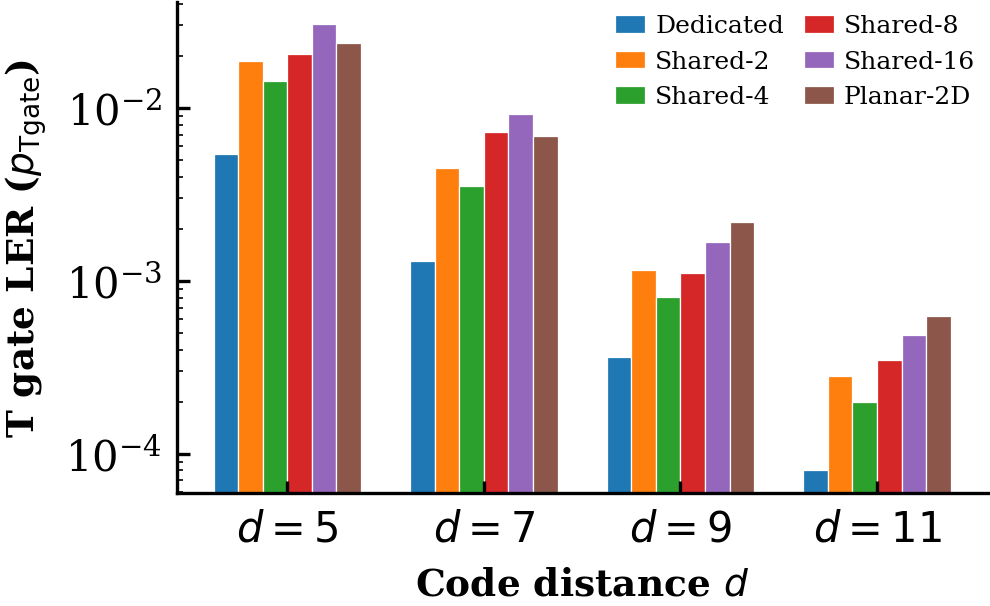

saved total_ler_1x_p50_v5.pdf


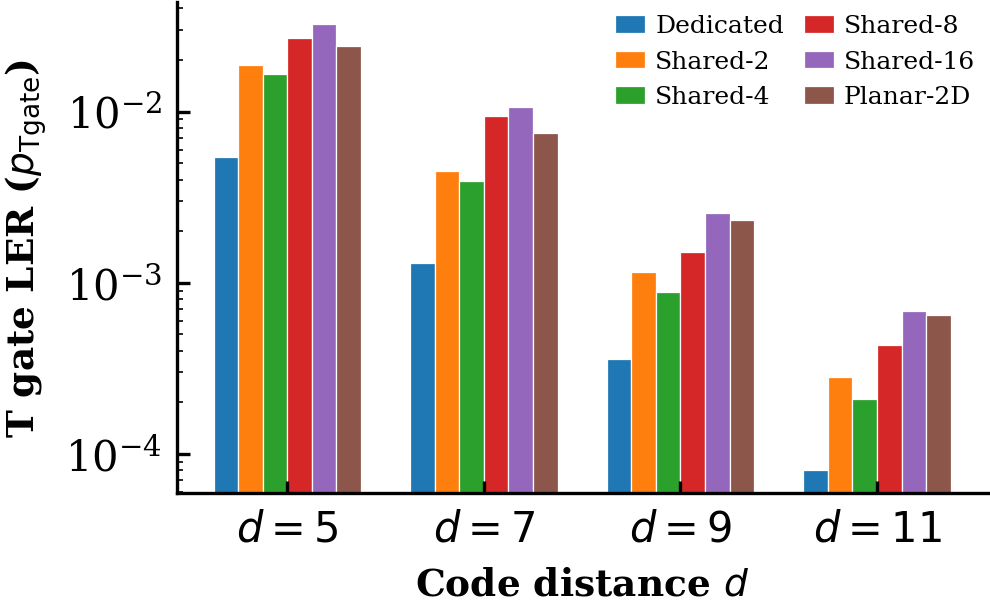

saved total_ler_1x_p90_v5.pdf


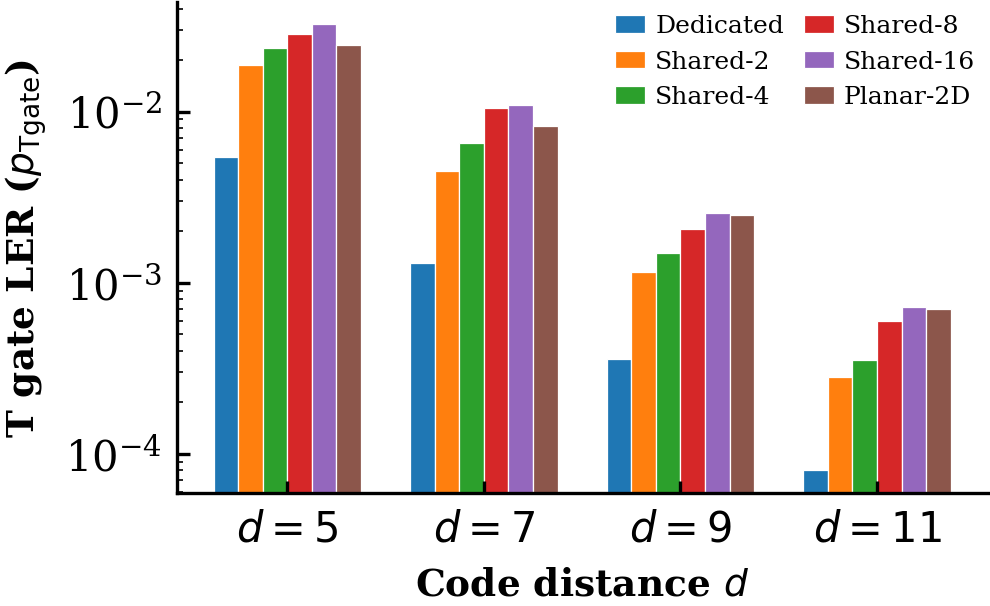

saved total_ler_5x_p10_v5.pdf


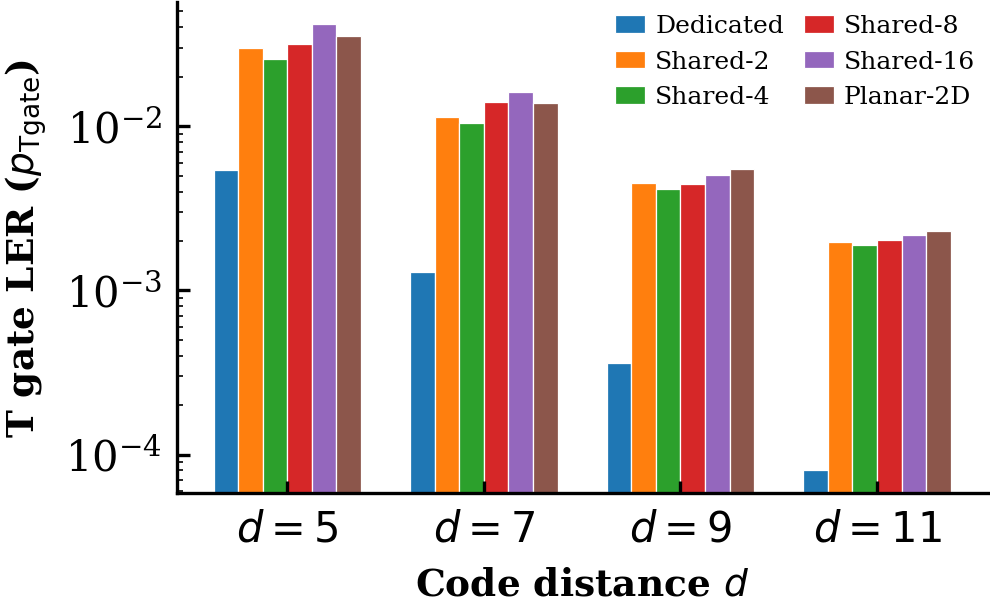

saved total_ler_5x_p50_v5.pdf


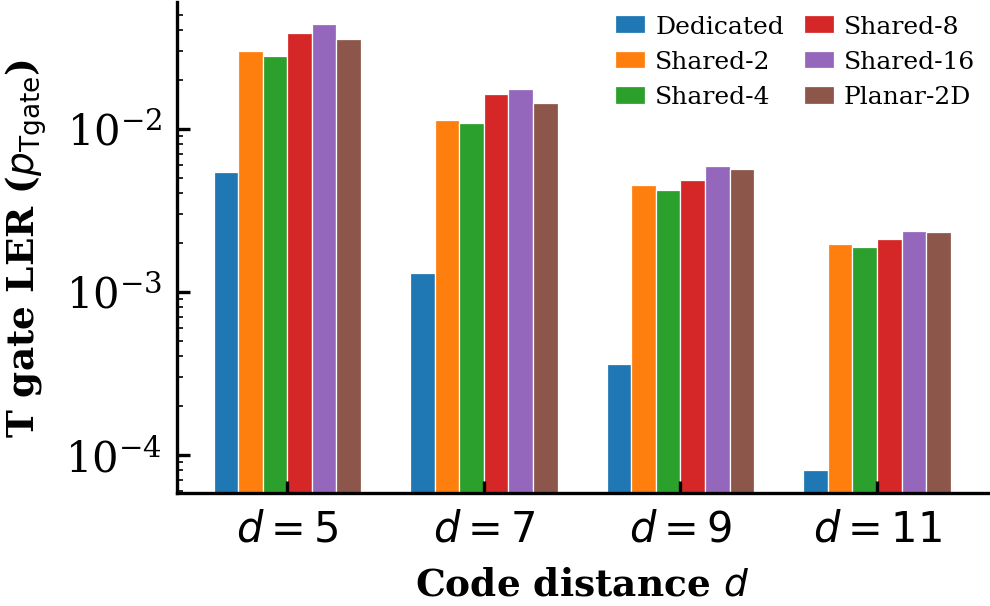

saved total_ler_5x_p90_v5.pdf


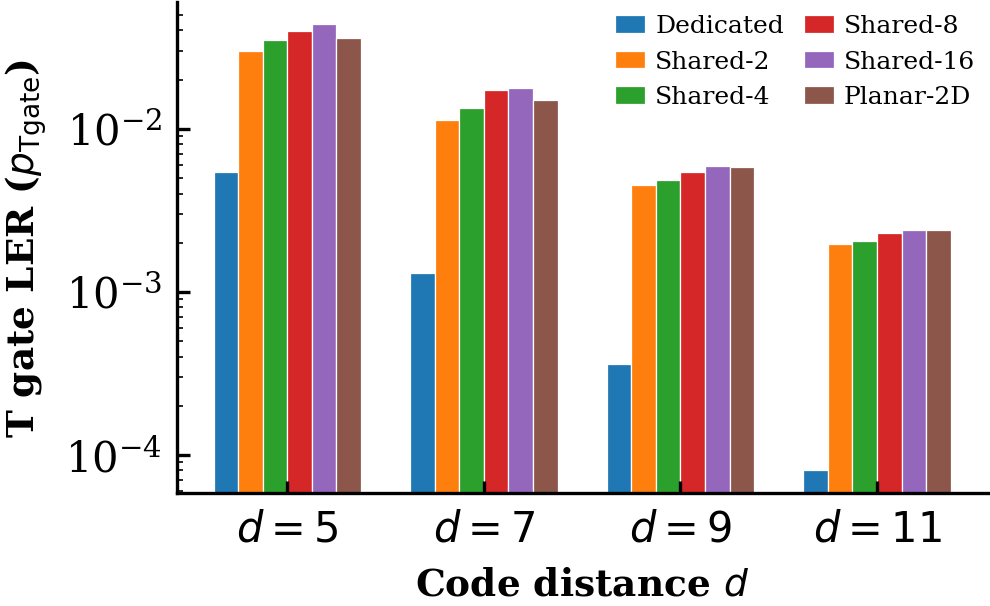

saved total_ler_10x_p10_v5.pdf


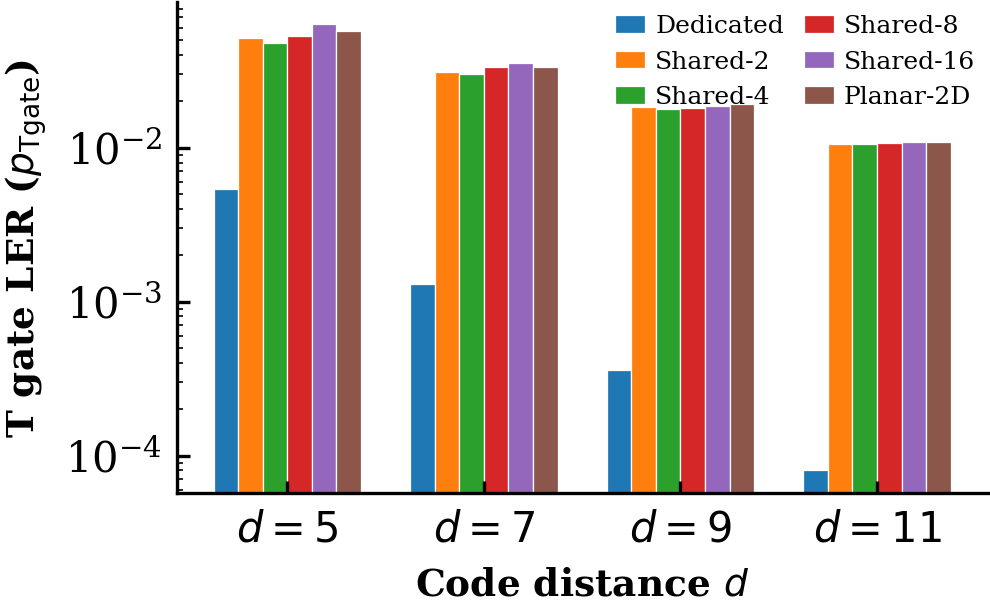

saved total_ler_10x_p50_v5.pdf


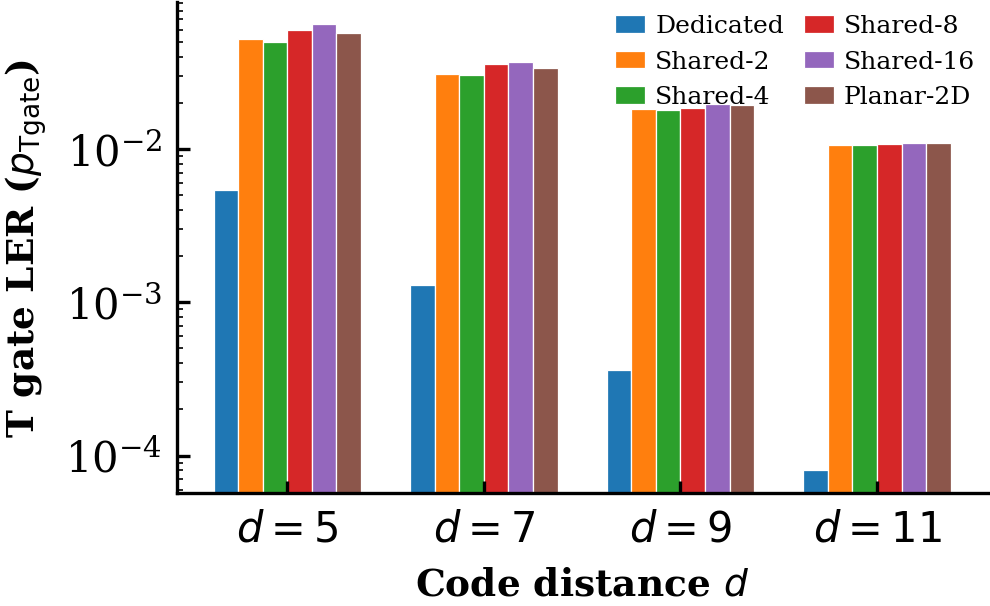

saved total_ler_10x_p90_v5.pdf


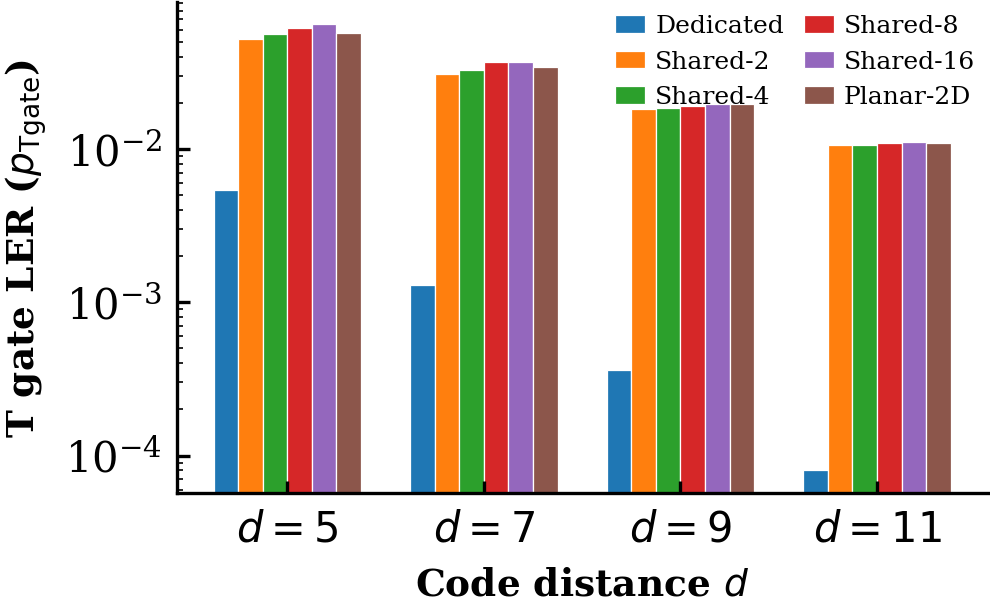

In [138]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from collections import defaultdict

COLUMNWIDTH_PT = 242
PT_PER_INCH    = 72.27
COL_IN         = COLUMNWIDTH_PT / PT_PER_INCH          # ~3.34 in
GOLDEN         = (1 + 5**0.5) / 2
FIG_SIZE       = (COL_IN, COL_IN / GOLDEN)             # ~3.34 × 2.06 in

plt.rcParams.update({
    "text.usetex":         False,
    "font.family":         "serif",
    "font.size":           8,
    "axes.titlesize":      8,
    "axes.labelsize":      9,
    "xtick.labelsize":     10,
    "ytick.labelsize":     10,
    "legend.fontsize":     6,
    "legend.title_fontsize": 6,
    "axes.linewidth":      0.8,
    "xtick.major.width":   0.8,
    "ytick.major.width":   0.8,
    "xtick.major.size":    3.0,
    "ytick.major.size":    3.0,
    "lines.linewidth":     0.8,
    "patch.linewidth":     0.4,
    "figure.dpi":          300,
    "savefig.dpi":         600,
    "savefig.bbox":        "tight",
    "savefig.pad_inches":  0.01,
})

MODES = [
    "ARCH_A",
    "ARCH_C_shared_2",
    "ARCH_C_shared_4",
    "ARCH_C_shared_8",
    "ARCH_C_shared_16",
    "no_hbm",
]

MODE_LABELS = {
    "ARCH_A":           r"Dedicated",
    "ARCH_C_shared_2":  r"Shared-2",
    "ARCH_C_shared_4":  r"Shared-4",
    "ARCH_C_shared_8":  r"Shared-8",
    "ARCH_C_shared_16": r"Shared-16",
    "no_hbm":           r"Planar-2D",
}

T_INTENSITY_LABELS = {
    "10":  "low",
    "50":  "medium",
    "90":  "high",
}


def plot_total_ler(df_hbm, hbm_label, t_intensity=None, p=P_TARGET, outfile=None):
    """
    df_hbm:       prepared LER dataframe for the HBM multiplier (df_1x/df_5x/df_10x)
    hbm_label:    string like "1", "5", "10" for title and filename
    t_intensity:  one of "10", "50", "90" (T-gate percentile), or None for all combined
    """
    # Filter routing data by T-gate intensity if specified
    if t_intensity is not None:
        df_r = df_routing[df_routing["t_intensity"] == t_intensity]
    else:
        df_r = df_routing

    ns = sorted(df_r["N"].unique())
    valid_ns = [n for n in ns if np.sqrt(n) <= max(DISTANCES)]
    if not valid_ns:
        return

    d_to_ns = defaultdict(list)
    for n in valid_ns:
        d_to_ns[snap_distance(n)].append(n)
    ds = sorted(d_to_ns.keys())

    # Prepare LER lookup tables
    df_planar_lookup = prepare_plot_df(df_baseline)
    df_planar_lookup = df_planar_lookup[df_planar_lookup["mode"] == 0]
    df_hbm_lookup    = prepare_plot_df(df_hbm)
    hbm_mode         = df_hbm["mode"].iloc[0]
    df_hbm_lookup    = df_hbm_lookup[df_hbm_lookup["mode"] == hbm_mode]

    x       = np.arange(len(ds))
    n_modes = len(MODES)
    width   = 0.75 / n_modes

    fig, ax = plt.subplots(figsize=FIG_SIZE)

    for i, mode in enumerate(MODES):
        lers = []
        for d in ds:
            vals = []
            for n in d_to_ns[d]:
                row = df_r[(df_r["N"] == n) & (df_r["mode"] == mode)]
                if row.empty:
                    continue
                msrd  = row["MSRD"].values[0]
                ler_p = lookup_ler(df_planar_lookup, d, p)
                ler_h = lookup_ler(df_hbm_lookup, d, p)
                v     = total_ler(msrd, ler_p, ler_h)
                if not np.isnan(v):
                    vals.append(v)
            lers.append(np.mean(vals) if vals else np.nan)

        offset = (i - n_modes / 2 + 0.5) * width
        ax.bar(
            x + offset, lers, width=width,
            label=MODE_LABELS[mode],
            edgecolor="white",
            linewidth=0.3,
        )

    ax.set_yscale("log")
    ax.set_xticks(x)
    ax.set_xticklabels([f"$d={d}$" for d in ds])
    ax.set_xlabel("Code distance $d$")
    ax.set_ylabel(r"T gate LER ($p_{\rm Tgate}$)")

    t_str = f"T-gate intensity: {T_INTENSITY_LABELS[t_intensity]}" if t_intensity else ""
    # ax.set_title(f"$p={p:.1e}$, HBM vertical coupling error rate $p'={hbm_label}p$\n{t_str}")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
    ax.yaxis.set_minor_locator(ticker.LogLocator(subs="all", numticks=10))
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())
    ax.tick_params(which="minor", length=1.5, width=0.4)

    ax.legend(
        # title="architecture",
        ncol=2,
        frameon=False,
        handlelength=1.2,
        handletextpad=0.4,
        columnspacing=0.8,
        borderpad=0,
    )

    fig.tight_layout(pad=0.3)
    fname = outfile or f"total_ler_{hbm_label}x.pdf"
    fig.savefig(figures_path + fname)
    print(f"saved {fname}")
    plt.show()


# Generate all combinations: 3 HBM multipliers × 3 T-gate intensities
HBM_DFS = {
    "1":  df_1x,
    "5":  df_5x,
    "10": df_10x,
}

for hbm_mult, df_hbm in HBM_DFS.items():
    for t_pct in ["10", "50", "90"]:
        plot_total_ler(
            df_hbm,
            hbm_label=hbm_mult,
            t_intensity=t_pct,
            outfile=f"total_ler_{hbm_mult}x_p{t_pct}_v5.pdf",
        )